# Optimized ISIC Training - Single GPU (GPU 0)

Key optimizations:
- Uses preprocessed HDF5 (no JPEG decode overhead)
- Larger batch size (128 vs 32)
- More workers (16 vs 4)
- Fast transforms only (removed rotation, color jitter)
- Persistent file handles (no repeated file opening)

Expected performance: 20-30 iterations/sec (vs 1-2 it/s before)

In [1]:
import pandas as pd
import h5py
import numpy as np
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import time

# Force single GPU (GPU 0)
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"GPU Name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB\n")

Using device: cuda
GPU Name: NVIDIA L40S
GPU Memory: 47.7 GB



## 1. Fast Dataset Class (Preprocessed HDF5)

In [2]:
class PreprocessedHDF5Dataset(Dataset):
    """
    Fast dataset for preprocessed HDF5 files.
    Images are already decoded and resized to 224x224.
    """
    
    def __init__(self, hdf5_path, metadata_df, transform=None, is_test=False):
        self.hdf5_path = hdf5_path
        self.transform = transform
        self.is_test = is_test
        self.hdf5_file = None  # Opened lazily per worker
        
        # Match metadata with available images
        with h5py.File(hdf5_path, 'r') as f:
            available_ids = set(f.keys())
        
        self.metadata = metadata_df[
            metadata_df['isic_id'].isin(available_ids)
        ].reset_index(drop=True)
        
        print(f"✓ Loaded {len(self.metadata)} images from {Path(hdf5_path).name}")
        
        if not is_test and 'target' in self.metadata.columns:
            dist = self.metadata['target'].value_counts()
            print(f"  Class distribution: {dist.to_dict()}")
    
    def _ensure_hdf5_open(self):
        """Open HDF5 file once per worker (not per image!)"""
        if self.hdf5_file is None:
            self.hdf5_file = h5py.File(self.hdf5_path, 'r', swmr=True)
    
    def __len__(self):
        return len(self.metadata)
    
    def __getitem__(self, idx):
        self._ensure_hdf5_open()
        
        row = self.metadata.iloc[idx]
        image_id = row['isic_id']
        
        # Load preprocessed array (FAST - already decoded and resized!)
        img_array = self.hdf5_file[image_id][:]
        
        # Convert to PIL for transforms
        image = Image.fromarray(img_array)
        
        if self.transform:
            image = self.transform(image)
        else:
            image = transforms.ToTensor()(image)
        
        if self.is_test:
            return image, image_id
        else:
            label = row['target']
            return image, label

## 2. Fast Transforms (No Resize, No Expensive Ops)

In [3]:
# Training: Only fast random augmentations
train_transform = transforms.Compose([
    # No resize needed - already 224x224!
    transforms.RandomHorizontalFlip(p=0.5),  # Fast
    transforms.RandomVerticalFlip(p=0.5),    # Fast
    # Removed RandomRotation - too expensive for baseline
    # Removed ColorJitter - too expensive for baseline
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation/Test: No augmentation
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Transforms configured:")
print("  Train: Horizontal/Vertical flips only (fast)")
print("  Val/Test: No augmentation\n")

Transforms configured:
  Train: Horizontal/Vertical flips only (fast)
  Val/Test: No augmentation



## 3. Load Metadata & Create Datasets

In [4]:
data_dir = Path('data')
train_metadata = pd.read_csv(data_dir / 'new-train-metadata.csv', low_memory=False)
test_metadata = pd.read_csv(data_dir / 'students-test-metadata.csv', low_memory=False)

print(f"Metadata loaded:")
print(f"  Training samples: {len(train_metadata):,}")
print(f"  Test samples: {len(test_metadata):,}")
print(f"  Target distribution: {train_metadata['target'].value_counts().to_dict()}\n")

# Split training data (80/20)
train_df, val_df = train_test_split(
    train_metadata, 
    test_size=0.2, 
    random_state=42,
    stratify=train_metadata['target']
)

print(f"Train/Val split: {len(train_df):,} / {len(val_df):,}\n")

# Create datasets with preprocessed files
print("Creating datasets...")
train_dataset = PreprocessedHDF5Dataset(
    hdf5_path=data_dir / 'train-image-preprocessed.hdf5',
    metadata_df=train_df,
    transform=train_transform,
    is_test=False
)

val_dataset = PreprocessedHDF5Dataset(
    hdf5_path=data_dir / 'train-image-preprocessed.hdf5',
    metadata_df=val_df,
    transform=val_transform,
    is_test=False
)

test_dataset = PreprocessedHDF5Dataset(
    hdf5_path=data_dir / 'test-image-preprocessed.hdf5',
    metadata_df=test_metadata,
    transform=val_transform,
    is_test=True
)

Metadata loaded:
  Training samples: 400,959
  Test samples: 100
  Target distribution: {0: 400616, 1: 343}

Train/Val split: 320,767 / 80,192

Creating datasets...
✓ Loaded 320767 images from train-image-preprocessed.hdf5
  Class distribution: {0: 320493, 1: 274}
✓ Loaded 80192 images from train-image-preprocessed.hdf5
  Class distribution: {0: 80123, 1: 69}
✓ Loaded 100 images from test-image-preprocessed.hdf5


## 4. Optimized DataLoaders

In [5]:
# OPTIMIZED SETTINGS for single GPU
BATCH_SIZE = 512  # Increased from 32 (L40S can handle this easily)
NUM_WORKERS = 24  # Increased from 4 (more parallel preprocessing)

print(f"\nDataLoader configuration:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Num workers: {NUM_WORKERS}")
print(f"  Pin memory: True")
print(f"  Persistent workers: True\n")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

print(f"Batches per epoch:")
print(f"  Train: {len(train_loader)} batches")
print(f"  Val: {len(val_loader)} batches")
print(f"  Test: {len(test_loader)} batches\n")


DataLoader configuration:
  Batch size: 512
  Num workers: 24
  Pin memory: True
  Persistent workers: True

Batches per epoch:
  Train: 627 batches
  Val: 157 batches
  Test: 1 batches



## 5. Model Architecture

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        
        # Convolutional blocks
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        
        # After 4 pooling: 224 -> 112 -> 56 -> 28 -> 14
        self.fc1 = nn.Linear(256 * 14 * 14, 512)
        self.fc2 = nn.Linear(512, 1)
        
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = self.pool(self.relu(self.conv4(x)))
        
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        
        return x

model = SimpleCNN().to(device)
print(f"Model created:")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Device: {next(model.parameters()).device}\n")

Model created:
  Parameters: 26,079,553
  Device: cuda:0



## 6. Training Setup

In [7]:
# Class weights for imbalance
class_counts = train_metadata['target'].value_counts()
pos_weight = torch.tensor([class_counts[0] / class_counts[1]]).to(device)
print(f"Class imbalance:")
print(f"  Negative: {class_counts[0]:,}")
print(f"  Positive: {class_counts[1]:,}")
print(f"  Pos weight: {pos_weight.item():.2f}\n")

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='max',
    patience=3,
    factor=0.5
)

print("Training setup:")
print(f"  Loss: BCEWithLogitsLoss (weighted)")
print(f"  Optimizer: Adam (lr=0.001, weight_decay=1e-5)")
print(f"  Scheduler: ReduceLROnPlateau (patience=3)\n")

Class imbalance:
  Negative: 400,616
  Positive: 343
  Pos weight: 1167.98

Training setup:
  Loss: BCEWithLogitsLoss (weighted)
  Optimizer: Adam (lr=0.001, weight_decay=1e-5)
  Scheduler: ReduceLROnPlateau (patience=3)



## 7. Training Functions

In [8]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    start_time = time.time()
    
    for images, labels in tqdm(loader, desc="Training", ncols=100):
        images = images.to(device, non_blocking=True)
        labels = labels.float().unsqueeze(1).to(device, non_blocking=True)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        all_preds.extend(torch.sigmoid(outputs).detach().cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    elapsed = time.time() - start_time
    epoch_loss = running_loss / len(loader)
    epoch_auc = roc_auc_score(all_labels, all_preds)
    
    return epoch_loss, epoch_auc, elapsed

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation", ncols=100):
            images = images.to(device, non_blocking=True)
            labels = labels.float().unsqueeze(1).to(device, non_blocking=True)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            all_preds.extend(torch.sigmoid(outputs).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(loader)
    epoch_auc = roc_auc_score(all_labels, all_preds)
    
    return epoch_loss, epoch_auc

## 8. Training Loop

In [9]:
NUM_EPOCHS = 20
best_auc = 0.0
history = {
    'train_loss': [], 'train_auc': [], 'train_time': [],
    'val_loss': [], 'val_auc': []
}

print("="*70)
print("STARTING TRAINING")
print("="*70)
print(f"Epochs: {NUM_EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Batches per epoch: {len(train_loader)}")
print(f"Images per epoch: {len(train_dataset):,}")
print("="*70 + "\n")

total_start = time.time()

for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*70}")
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"{'='*70}")
    
    # Train
    train_loss, train_auc, train_time = train_epoch(
        model, train_loader, criterion, optimizer, device
    )
    
    # Validate
    val_loss, val_auc = validate(model, val_loader, criterion, device)
    
    # Save metrics
    history['train_loss'].append(train_loss)
    history['train_auc'].append(train_auc)
    history['train_time'].append(train_time)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)
    
    # Print results
    print(f"\nResults:")
    print(f"  Train Loss: {train_loss:.4f} | Train AUC: {train_auc:.4f} | Time: {train_time:.1f}s")
    print(f"  Val Loss:   {val_loss:.4f} | Val AUC:   {val_auc:.4f}")
    print(f"  Speed: {len(train_loader)/train_time:.1f} it/s | "
          f"{len(train_dataset)/train_time:.0f} img/s")
    
    # Save best model
    if val_auc > best_auc:
        best_auc = val_auc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_auc': val_auc,
        }, 'best_simple_cnn.pth')
        print(f"  ✓ Saved best model (AUC: {best_auc:.4f})")
    
    # Update learning rate
    scheduler.step(val_auc)
    current_lr = optimizer.param_groups[0]['lr']
    print(f"  Learning rate: {current_lr:.6f}")

total_time = time.time() - total_start

print(f"\n{'='*70}")
print("TRAINING COMPLETE")
print(f"{'='*70}")
print(f"Total time: {total_time/60:.1f} minutes")
print(f"Best validation AUC: {best_auc:.4f}")
print(f"Average epoch time: {np.mean(history['train_time']):.1f}s")
print(f"Average speed: {np.mean([len(train_dataset)/t for t in history['train_time']]):.0f} img/s")
print(f"{'='*70}\n")

STARTING TRAINING
Epochs: 20
Batch size: 512
Batches per epoch: 627
Images per epoch: 320,767


Epoch 1/20


Training: 100%|███████████████████████████████████████████████████| 627/627 [02:21<00:00,  4.44it/s]

Validation: 100%|█████████████████████████████████████████████████| 157/157 [00:16<00:00,  9.26it/s]




Results:
  Train Loss: 1.6732 | Train AUC: 0.4833 | Time: 141.3s
  Val Loss:   1.3996 | Val AUC:   0.5060
  Speed: 4.4 it/s | 2269 img/s
  ✓ Saved best model (AUC: 0.5060)
  Learning rate: 0.001000

Epoch 2/20
  ✓ Saved best model (AUC: 0.5060)
  Learning rate: 0.001000

Epoch 2/20


Training: 100%|███████████████████████████████████████████████████| 627/627 [02:15<00:00,  4.63it/s]

Validation: 100%|█████████████████████████████████████████████████| 157/157 [00:16<00:00,  9.49it/s]




Results:
  Train Loss: 1.4739 | Train AUC: 0.4865 | Time: 135.3s
  Val Loss:   1.3985 | Val AUC:   0.5116
  Speed: 4.6 it/s | 2370 img/s
  ✓ Saved best model (AUC: 0.5116)
  Learning rate: 0.001000

Epoch 3/20
  ✓ Saved best model (AUC: 0.5116)
  Learning rate: 0.001000

Epoch 3/20


...


Results:
  Train Loss: 1.3836 | Train AUC: 0.4975 | Time: 136.7s
  Val Loss:   1.3996 | Val AUC:   0.5000
  Speed: 4.6 it/s | 2347 img/s
  Learning rate: 0.000063

Epoch 19/20


Training: 100%|███████████████████████████████████████████████████| 627/627 [02:16<00:00,  4.59it/s]

Validation: 100%|█████████████████████████████████████████████████| 157/157 [00:16<00:00,  9.60it/s]




Results:
  Train Loss: 1.3838 | Train AUC: 0.4786 | Time: 136.6s
  Val Loss:   1.3996 | Val AUC:   0.5000
  Speed: 4.6 it/s | 2348 img/s
  Learning rate: 0.000063

Epoch 20/20


Training: 100%|███████████████████████████████████████████████████| 627/627 [02:16<00:00,  4.58it/s]

Validation: 100%|█████████████████████████████████████████████████| 157/157 [00:16<00:00,  9.63it/s]


Results:
  Train Loss: 1.3861 | Train AUC: 0.5039 | Time: 136.9s
  Val Loss:   1.3996 | Val AUC:   0.5000
  Speed: 4.6 it/s | 2343 img/s
  Learning rate: 0.000063

TRAINING COMPLETE
Total time: 51.2 minutes
Best validation AUC: 0.5116
Average epoch time: 136.7s
Average speed: 2346 img/s



## 9. Plot Training History

✓ Training plots saved: training_history.png



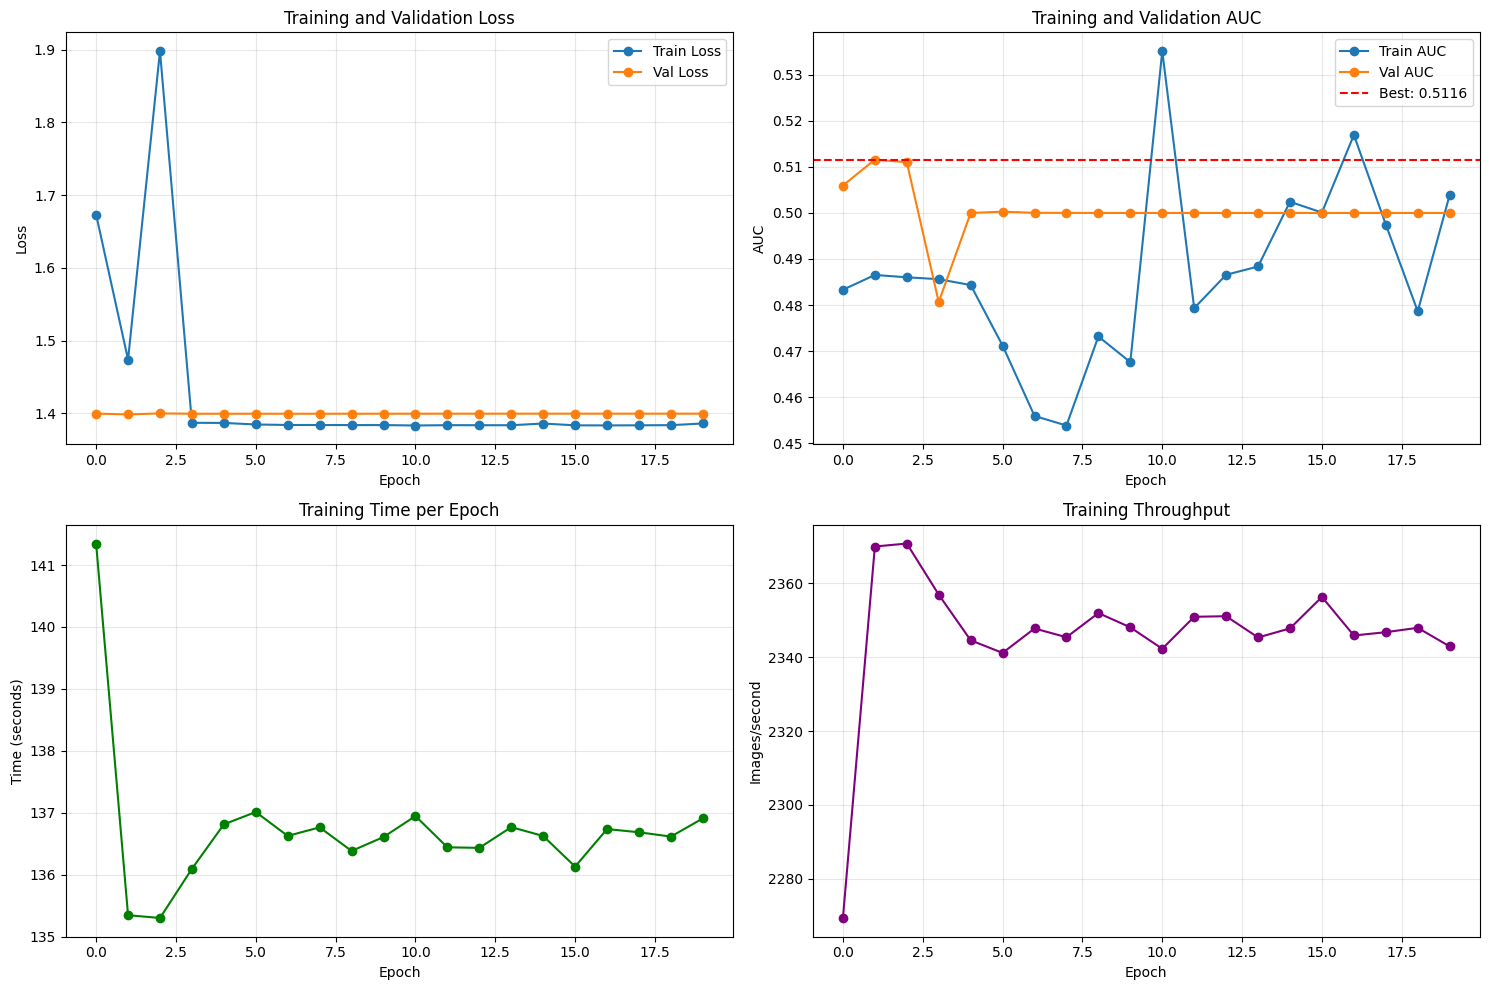

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0, 0].plot(history['val_loss'], label='Val Loss', marker='o')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# AUC
axes[0, 1].plot(history['train_auc'], label='Train AUC', marker='o')
axes[0, 1].plot(history['val_auc'], label='Val AUC', marker='o')
axes[0, 1].axhline(y=best_auc, color='r', linestyle='--', label=f'Best: {best_auc:.4f}')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('AUC')
axes[0, 1].set_title('Training and Validation AUC')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Training time per epoch
axes[1, 0].plot(history['train_time'], marker='o', color='green')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Time (seconds)')
axes[1, 0].set_title('Training Time per Epoch')
axes[1, 0].grid(True, alpha=0.3)

# Images per second
img_per_sec = [len(train_dataset)/t for t in history['train_time']]
axes[1, 1].plot(img_per_sec, marker='o', color='purple')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Images/second')
axes[1, 1].set_title('Training Throughput')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
print("✓ Training plots saved: training_history.png\n")
plt.show()

## 10. Generate Test Predictions

In [11]:
print("Generating test predictions...")
checkpoint = torch.load('best_simple_cnn.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

test_ids = []
test_preds = []

with torch.no_grad():
    for images, img_ids in tqdm(test_loader, desc="Testing", ncols=100):
        images = images.to(device, non_blocking=True)
        outputs = model(images)
        probs = torch.sigmoid(outputs).cpu().numpy()
        
        test_ids.extend(img_ids)
        test_preds.extend(probs.flatten())

# Create submission
submission = pd.DataFrame({
    'isic_id': test_ids,
    'target': test_preds
})

submission.to_csv('submission_simple_cnn.csv', index=False)

print(f"\n{'='*70}")
print("SUBMISSION GENERATED")
print(f"{'='*70}")
print(f"File: submission_simple_cnn.csv")
print(f"Shape: {submission.shape}")
print(f"\nPrediction statistics:")
print(submission['target'].describe())
print(f"{'='*70}\n")

Generating test predictions...


Testing: 100%|████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.23it/s]


SUBMISSION GENERATED
File: submission_simple_cnn.csv
Shape: (100, 2)

Prediction statistics:
count    100.000000
mean       0.512395
std        0.000081
min        0.511931
25%        0.512388
50%        0.512403
75%        0.512434
max        0.512457
Name: target, dtype: float64



## 11. Final Summary

In [12]:
print("="*70)
print("TRAINING SUMMARY")
print("="*70)
print(f"Dataset: {len(train_dataset):,} train, {len(val_dataset):,} val, {len(test_dataset):,} test")
print(f"Model: SimpleCNN ({sum(p.numel() for p in model.parameters()):,} parameters)")
print(f"Batch size: {BATCH_SIZE}")
print(f"Workers: {NUM_WORKERS}")
print(f"Epochs trained: {NUM_EPOCHS}")
print(f"Total training time: {total_time/60:.1f} minutes")
print(f"Best validation AUC: {best_auc:.4f}")
print(f"Average throughput: {np.mean([len(train_dataset)/t for t in history['train_time']]):.0f} images/sec")
print(f"\nFiles saved:")
print(f"  - best_simple_cnn.pth (model checkpoint)")
print(f"  - submission_simple_cnn.csv (test predictions)")
print(f"  - training_history.png (plots)")
print("="*70)

TRAINING SUMMARY
Dataset: 320,767 train, 80,192 val, 100 test
Model: SimpleCNN (26,079,553 parameters)
Batch size: 512
Workers: 24
Epochs trained: 20
Total training time: 51.2 minutes
Best validation AUC: 0.5116
Average throughput: 2346 images/sec

Files saved:
  - best_simple_cnn.pth (model checkpoint)
  - submission_simple_cnn.csv (test predictions)
  - training_history.png (plots)
